## Análisis y Procesamiento de Señales, 2C 2026
### Escuela de Ciencia y Tecnología
#### Iara Alvarez Costa

# Tarea Semanal N°1

Utilizando siempre N = 1000 muestras. Se pide sintetizar:

    - Señal sinusoidal de 2 KHz que tenga al menos 10 puntos por período.
    - Misma señal con 2 W de potencia media y desfasada en π/2.
    - Una secuencia aleatoria de ruido normalmente distribuido con DC (valor medio) 0V y varianza 0.1 W.
    - Una secuencia aleatoria de ruido uniformemente distribuido con DC (valor medio) 0V y varianza 0.1 W. 
    - Un pulso rectangular de la misma frecuencia, 1 W de potencia y ciclo de actividad del 50%.
    
Para cada señal visualice el módulo de la transformada de Fourier.

# Resolución:


### Señales
Primero, busco simular una señal senoidal ruidosa de 2 watts de potencia, cuyo ruido acompañante se pueda programar a través de la relación SNR entre potencias. 
Primero voy a generar una señal senoidal de la forma $x_1(t)=A.Sin(2π.f.t)$ donde $A$ sea su amplitud máxima. 
La potencia media de una señal se puede calcular como:
<div align="center"> $P_x =\frac{1}{T}.∫_0^Tx^2(t)  dt $ </div>

Para una senoide $Sin^2 (x)$, su valor medio es $\frac{1}{2}$: $P_x =\frac{A^2}{2}$. Entonces, si quiero que la potencia media de mi señal sea de 2 Watts: $2=\frac{A^2}{2}$, y la amplitud de la señal será $A=2$.
Además de esto, quiero que la señal tenga al menos 10 puntos de muestreo por periodo de la señal ($T_x$), es decir $f_{sampling}≥10.f_x$. Entonces, para una $f_x = 2kHz$, $f_s ≥ 20kHz$



Ahora debo definir los parametros necesarios para simular otra señal diferente en forma de pulso rectangular. Debe tener la misma frecuencia que la senoidal (2kHz), una potencia media de 1 Watt, y ciclo de actividad del 50%; para esto, puedo relacionar la potencia de la señal con su amplitud, igual que con la senoidal: $P_x =\frac{1}{T}.∫_0^Tx^2(t)  dt $.

Una señal cuadrada de media 0, ciclo de actividad del 50% del periodo, y amplitud máxima $B$ tiene la forma:
<div align="center"> $x_2(t) = 
\begin{cases} 
B, & \frac{T}{2} \\ 
-B, & \frac{T}{2}
\end{cases}$ </div>

El valor medio de esta señal es 1, entonces, su potencia: $P_x = B^2$, y si quiero que la potencia media sea de 1 watt, $B = 1$



### Secuencias de ruido
Ahora, también debo simular las secuencias de ruido para acompañar a las señales. Esto lo haré generando dos secuencias de números aleatorios; la primera secuencia será de distribucion normal, y la voy a generar con la función “$np.random.normal(µ , σ , N)$”, cuyos argumentos son $µ = $media del ruido, $σ =  $desviación estándar del ruido, y $N =$ cant. de muestras. 

Ya sé que el valor medio debe ser $µ = 0$, lo cual me permitirá relacionar la potencia del ruido con su varianza y desviación estándar de la forma $P_r=Var_r=σ^2$. 
Sé que la relación entre las potencias de la señal y el ruido está dada por: 
<div align="center"> $SNR_{dB}=10.log(\frac{P_x}{P_r})$ </div>
donde $P_x$ es la potencia de mi señal $(2W)$, y $P_r$ la potencia del ruido. Entonces, si especifico el valor deseado de SNR, podré obtener $P_r=10^{-\frac{SNR_{dB}}{10}}$ y, por lo tanto, $σ=√(P_r)$ para el ruido de distribucion normal.



Para la configuración del ruido de distribución uniforme $r~U(a,b)$ también busco una media = 0, entonces puedo relacionar sus limites de amplitud como $µ = a+b/2 = 0$, por lo tanto $a$ y $b$ deben ser nros opuestos $(a=-b)$.
Si ademas quiero que la varianza del ruido $\frac{(b-a)^2}{12}$ sea $0.1$...
<div align="center">$ 0.1 = \frac{(b-(-b))^2}{12} = \frac{b^2}{3}      ⟹      b = √(3*0.1) ≈ 0.548$ </div>

Tengo así todos los parámetros necesarios para generar los dos tipos de ruido.


In [38]:
#Importacion de modulos

import numpy as np
import matplotlib.pyplot as plt
import scipy


In [39]:
" ------------------------------------------------------------ Defino valores necesarios ------------------------------------------------------------"

"Ctes. señal senoidal"
fs = 20000 #Frecuencia muestreo [Hz] 
N = 1000 #Cant. muestras
vmax = 2 #Amp max senoidal
dc = 0 #Offset senoidal
ff = 2000 #Frecuencia sinusoidal [Hz]
ph = np.pi/2 #Fase sinusoidal [rad]

"Ctes. señal cuadrada"
fs_sq = fs
vmax_sq = 1 #La amplitud maxima debe ser = 1 para que la potencia sea 1 watt
dc_sq = dc
ph_sq = ph
duty = 0.5 #Ciclo de actividad 

"Ctes. secuencias ruido"
SNR = 13 #Relación potencia señal/ruido [dB]
Psen = 2 #Potencia media senoide [Watt]
ur = 0 #Media del ruido 



In [40]:
" ------------------------------------------------------------ Armo funciones necesarias ------------------------------------------------------------"

"Señales"
# Generador de señal senoidal
def gen_sin (vmax = 1, dc = 0, ff = 1, ph=0, nn = N, fs = fs):

    #genero un vector de valores de 0 a N/fs segundos a intervalos de 1/fs
    tt = np.arange(0, stop=nn/fs, step=1/fs)
    #genero un vector con los valores de 'dc + vmax.Sen(2pi.ff.tt + ph)' para cada valor de tt
    xx = dc + vmax * np.sin (2 * np.pi * ff * tt + ph)
    
    return tt, xx 


# Generador de señal cuadrada
def gen_square (vmax = 1, dc = 0, ff = 1, ph = 0, nn = N, fs = fs, duty = 0.5):

    #genero un vector de valores de 0 a N/fs segundos a intervalos de 1/fs
    tt = np.arange(0, stop=nn/fs, step=1/fs)
    #genero un vector con los valores de 'dc + vmax.Sen(2pi.ff.tt + ph)' para cada valor de tt
    xx = dc + vmax * scipy.signal.square(2*np.pi*ff*tt, duty)
    
    return tt, xx 

"Secuencias de ruido"
# Generador de ruido normal
def gen_noise_norm (SNR = SNR, Px = 1, ur = ur, nn = N):

    #despejo la potencia del ruido en función de SNR y Psen    
    Pr = Px / (10**(SNR/10))
     
    #calculo la desviación estandar del ruido en base a Pr (Pr = σr^2)
    desv_est_r = np.sqrt(Pr)
    
    #genero un vector de nros aleatorios de distribucion normal
    ruido = np.random.normal(ur, desv_est_r, nn)
    
    return ruido


# Generador de ruido uniforme
def gen_noise_unif (SNR = SNR, Px = 1, nn = N):

    #despejo la potencia del ruido en función de SNR y Psen    
    Pr = Px / (10**(SNR/10))
     
    #calculo el parametro b
    b = np.sqrt(3 * Pr)
    
    #genero un vector de nros aleatorios de distribucion uniforme
    ruido = np.random.uniform(-b, b, nn)
    
    return ruido



Primero voy a generar un set de señales con baja frecuencia para poder observar claramente el patron de las señales:

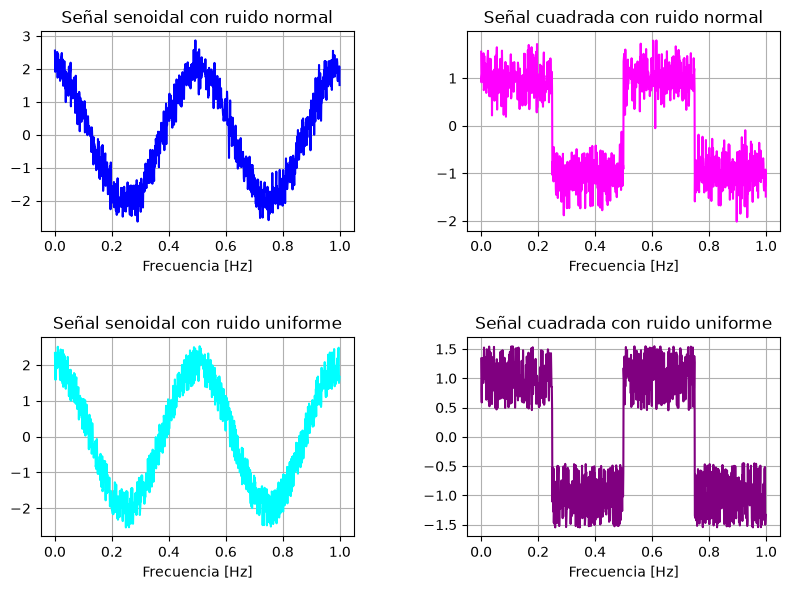

In [60]:
"Generacion de señales"
#Invoco la funciones generadoras de señales
tt, xsen = gen_sin( vmax, dc, 2, ph, N, N) 
tt_sq, xsquare = gen_square(vmax_sq, dc_sq, 2, ph_sq, N, N, duty) 

"Generacion de ruido"
#Invoco la funciones generadoras de ruido
ruido_norm = gen_noise_norm (SNR, Psen, ur, N)
ruido_unif = gen_noise_unif (SNR, Psen, N)

#Armo manualmente las señales ruidosas
noisy_xsen_norm = xsen + ruido_norm
noisy_xsen_unif = xsen + ruido_unif
noisy_xsquare_norm = xsquare + ruido_norm
noisy_xsquare_unif = xsquare + ruido_unif

"Grafico señales para comprobar"
fig, axs = plt.subplots(2, 2, figsize=(8, 6))

# Gráfico senoidal con ruido normal (superior izquierda)
axs[0, 0].plot(tt, noisy_xsen_norm, color='blue')
axs[0, 0].set_title('Señal senoidal con ruido normal')

#Gráfico senoidal con ruido uniforme (inferior izquierda)
axs[1, 0].plot(tt, noisy_xsen_unif, color='cyan')
axs[1, 0].set_title('Señal senoidal con ruido uniforme')

#Gráfico cuadrada con ruido normal (superior derecha)
axs[0, 1].plot(tt, noisy_xsquare_norm , color='magenta')
axs[0, 1].set_title('Señal cuadrada con ruido normal')

#Gráfico cuadrada con ruido uniforme (inferior derecha)
axs[1, 1].plot(tt, noisy_xsquare_unif, color='purple')
axs[1, 1].set_title('Señal cuadrada con ruido uniforme')

for ax in axs.flat:
    ax.set_xlabel("Frecuencia [Hz]")
    ax.grid()
    
plt.tight_layout(w_pad=5, h_pad=3)
plt.show()


#### Ahora genero las funciones que me pide el enunciado:

In [61]:
#Señales
tt, xsen = gen_sin( vmax, dc, ff, ph, N, fs) 
tt_sq, xsquare = gen_square(vmax_sq, dc_sq, ff, ph_sq, N, fs_sq, duty) 

#Secuencias de ruido
ruido_norm = gen_noise_norm (SNR, Psen, ur, N)
ruido_unif = gen_noise_unif (SNR, Psen, N)

#Señales ruidosas
noisy_xsen_norm = xsen + ruido_norm
noisy_xsen_unif = xsen + ruido_unif
noisy_xsquare_norm = xsquare + ruido_norm
noisy_xsquare_unif = xsquare + ruido_unif


Me interesa visualizar el espectro de modulo de las DFTs, así que primero calculo la fft de cada onda:

In [62]:
#Calculo fft de las 4 señales ruidosas que armé
xsen_norm_fft = np.fft.fft(noisy_xsen_norm) 
xsen_unif_fft = np.fft.fft(noisy_xsen_unif)
xsq_norm_fft = np.fft.fft(noisy_xsquare_norm)
xsq_unif_fft = np.fft.fft(noisy_xsquare_unif)


De estas señales transformadas me interesa solo observar su fft hasta la frecuencia de Nyquist $(\frac{f_s}{2})$, ya que las señales son simetricas respecto a la misma, por lo tanto, busco quedarme con la mitad del espectro, que equivale a la mitad de las muestras $(\frac{N}{2})$

In [63]:
#Selecciono las muestras de las señales transformadas hasta la frec de Nyquist (N/2)

A = xsen_norm_fft[:N//2]
AdB = 20*np.log10(np.abs(A)) #Expreso el espectro en decibeles para mejor visualizacion

B = xsen_unif_fft[:N//2]
BdB = 20*np.log10(np.abs(B))

C = xsq_norm_fft[:N//2]
CdB = 20*np.log10(np.abs(C))

D = xsq_unif_fft[:N//2]
DdB = 20*np.log10(np.abs(D))


Finalmente, grafico los espectros del módulo de cada una de las señales transformadas:

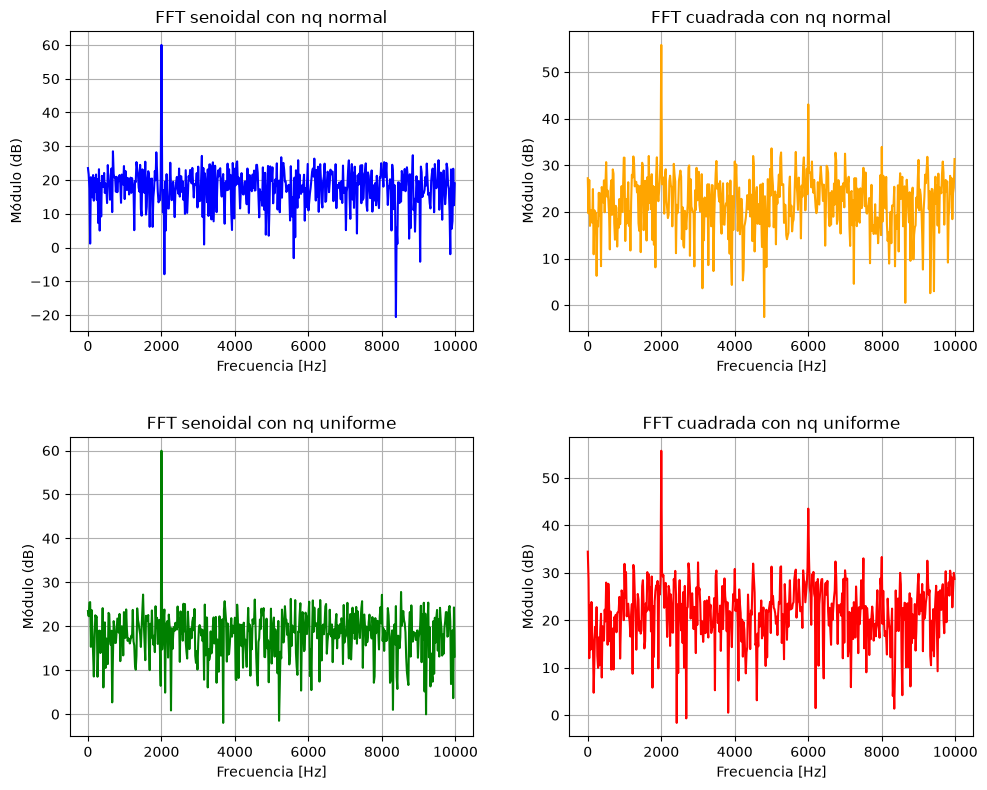

In [64]:
#Armo vector de frecuencias
frec = np.arange(N//2) * fs/N

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

axs[0, 0].plot(frec, AdB, color='blue')
axs[0, 0].set_title('FFT senoidal con nq normal')

axs[1, 0].plot(frec, BdB, color='green')
axs[1, 0].set_title('FFT senoidal con nq uniforme')

axs[0, 1].plot(frec, CdB, color='orange')
axs[0, 1].set_title('FFT cuadrada con nq normal')

axs[1, 1].plot(frec, DdB, color='red')
axs[1, 1].set_title('FFT cuadrada con nq uniforme')

for ax in axs.flat:
    ax.set_xlabel("Frecuencia [Hz]")
    ax.set_ylabel("Módulo (dB)")
    ax.grid()

plt.tight_layout(w_pad=3, h_pad=3)
plt.show()
